# Zadanie 1: Klasteryzacja klientów

<div style="display: flex; justify-content: center;">
<img src=".//Images//bikes_market.png" alt="bikes_market" width="600" height="200" style="margin: 10px;"/>
</div>

**Segmentacja klientów na podstawie danych demograficznych i stylu życia**

**Opis zadania:**

Jako analityk danych pracujesz dla firmy zajmującej się sprzedażą rowerów. Twoim zadaniem jest przeprowadzenie analizy segmentacyjnej klientów na podstawie ich cech demograficznych i stylu życia.

Celem segmentacji jest:

* lepsze zrozumienie różnych typów klientów,
* dostosowanie oferty marketingowej do poszczególnych segmentów,
* wyodrębnienie grup z największym potencjałem zakupowym.

**Zakres pracy:**

1. **Przygotuj dane do analizy (`Dataset - Bikes.xlsx`):**

   * wybierz istotne zmienne do klasteryzacji (np. `Income`, `Age`, `Children`, `Cars`, `Commute Distance`, `Education`),
   * zakoduj zmienne kategoryczne (np. `Education`, `Commute Distance`) w postaci liczbowej,
   * przeskaluj dane.

2. **Wykonaj klasteryzację:**

   * **K-means (3 klastry)**,

3. **Wizualizuj wyniki:**

   * zastosuj wykres 2D (PCA) porównujący klastry.
  
3. **Zinterpretuj uzyskane klastry:**

   * opisz każdy segment: czym się charakteryzuje, co go odróżnia od innych,
   * sprawdź, czy w klastrach różni się częstość zakupu roweru (`Purchased Bike`).

---

In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

<span style="color: red; font-weight: bold;">Wczytanie zbioru</span>

In [2]:
# dane z pliku Excel
file_path = "./data/Dataset - Bikes.xlsx"

# Wczytanie danych z arkusza
df_bikes = pd.read_excel(file_path)

# Podgląd danych
df_bikes.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,No
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,55,No
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,No
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Yes
4,13507,Married,Female,10000,2,Partial College,Manual,Yes,0,1-2 Miles,Europe,50,No


<span style="color: red; font-weight: bold;">Wybór cech do analizy</span>

In [3]:
# Wybór cech do analizy


<span style="color: red; font-weight: bold;">Kodowanie zmiennych kategorycznych</span>

In [4]:
# Kodowanie zmiennych kategorycznych


<span style="color: red; font-weight: bold;">Standaryzacja</span>

In [5]:
# Standaryzacja


<span style="color: red; font-weight: bold;">Klasteryzacja KMeans (3 klastry)</span>

In [6]:
# Klasteryzacja KMeans (3 klastry)


<span style="color: red; font-weight: bold;">Redukcja wymiarowości do 2D (PCA, n_components=2) i wizualizacja</span>

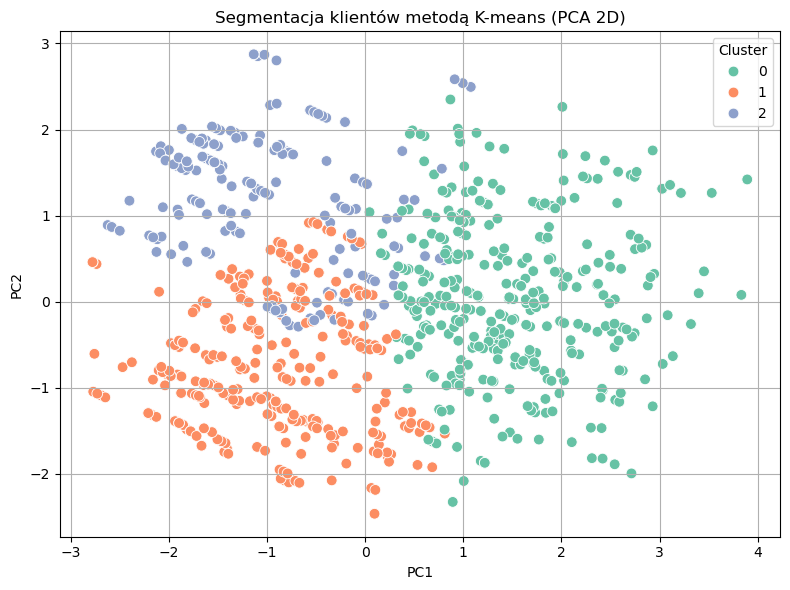

In [7]:
# Redukcja wymiarowości do 2D (PCA)


# Wizualizacja


Powyższy wykres przedstawia wynik segmentacji klientów metodą K-means na podstawie danych demograficznych, zredukowanych do dwóch głównych składowych (PCA). Każdy punkt to klient, a kolory odpowiadają 3 wyodrębnionym klastrom.

<span style="color: red; font-weight: bold;">Zinterpretuj uzyskane klastry</span>

---

# Zadanie 2: Analiza koszykowa – reguły asocjacyjne

<div style="display: flex; justify-content: center;">
<img src=".//Images//bikes.png" alt="bikes" width="600" height="200" style="margin: 10px;"/>
</div>

**Odkrywanie powiązań zakupowych pomiędzy produktami w danych sprzedażowych**

---

**Opis zadania:**

Twoim zadaniem jest przeprowadzenie analizy koszykowej (market basket analysis) na danych z zamówień klientów. Celem jest identyfikacja produktów, które są często kupowane razem, w celu:

* lepszego zrozumienia zachowań zakupowych klientów,
* tworzenia promocji wiązanych („kup X, a otrzymasz zniżkę na Y”),
* optymalizacji układu produktów w sklepie.

---

**Zakres pracy:**

1. **Przygotuj dane (`Dataset - Associate`):**

   * potraktuj każde `Order Number` jako osobną transakcję (koszyk),
   * każda transakcja powinna zawierać listę nazw produktów.

2. **Przeprowadź kodowanie danych:**

   * zastosuj `TransactionEncoder` z `mlxtend.preprocessing`,
   * uzyskaj macierz binarną: wiersze = transakcje, kolumny = produkty.

3. **Zidentyfikuj częste zestawy produktów:**

   * użyj funkcji `apriori()` z `mlxtend.frequent_patterns`,
   * ustal minimalne wsparcie (support), np. 1–2%.

4. **Wygeneruj reguły asocjacyjne:**

   * zastosuj `association_rules()` z odpowiednimi progami `confidence` i `lift`,
   * posortuj i zaprezentuj najciekawsze reguły.

5. **Zinterpretuj wyniki:**

   * opisz, które produkty są najczęściej kupowane razem,

---

**Dodatkowo (opcjonalnie):**

* Stwórz wykres `support vs confidence` (kolor = lift),
* Przeanalizuj wpływ ustawienia różnych progów `support` i `confidence`.

---

In [22]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [23]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

<span style="color: red; font-weight: bold;">Wczytanie zbioru</span>

In [24]:
# Ścieżka do pliku
file_path = "./data/Dataset - Associate.xlsx"

# Wczytanie danych z arkusza "Associate"
df_associate = pd.read_excel(file_path)

# Podgląd danych
df_associate.head()

,Order Number,Category,Product,Product Price
0,SO61269,Helmets,Sport-100,53.99
1,SO61269,Jerseys,Long-Sleeve Logo Jersey,49.99
2,SO61270,Fenders,Fender Set - Mountain,21.98
3,SO61271,Tires and Tubes,LL Road Tire,21.49
4,SO61271,Tires and Tubes,Patch kit,564.99


In [25]:
# Połączenie 'Product' i 'Category' w jedną kolumnę, np. 'Product (Category)'
df_associate['Product_Full'] = df_associate['Product'] + ' (' + df_associate['Category'] + ')'

# Usunięcie oryginalnych kolumn 'Product' i 'Category', zostawiając tylko 'Product_Full'
df_associate = df_associate.drop(columns=['Product', 'Category', 'Product Price'])

In [26]:
df_associate.shape

(32265, 2)

In [27]:
df_associate.head()

,Order Number,Product_Full
0,SO61269,Sport-100 (Helmets)
1,SO61269,Long-Sleeve Logo Jersey (Jerseys)
2,SO61270,Fender Set - Mountain (Fenders)
3,SO61271,LL Road Tire (Tires and Tubes)
4,SO61271,Patch kit (Tires and Tubes)


<span style="color: red; font-weight: bold;">Grupowanie produktów według numeru zamówienia</span>

<span style="color: red; font-weight: bold;">Kodowanie transakcji</span>

In [29]:
# Kodowanie transakcji


<span style="color: red; font-weight: bold;">Zidentyfikuj częste zestawy produktów</span>

In [30]:
# Apriori – zestawy częste (min_support=0.01)


<span style="color: red; font-weight: bold;">Wygeneruj reguły asocjacyjne, zaprezentuj najciekawsze reguły</span>

<span style="color: red; font-weight: bold;">Zinterpretuj wyniki</span>